In [17]:
import os
import json
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

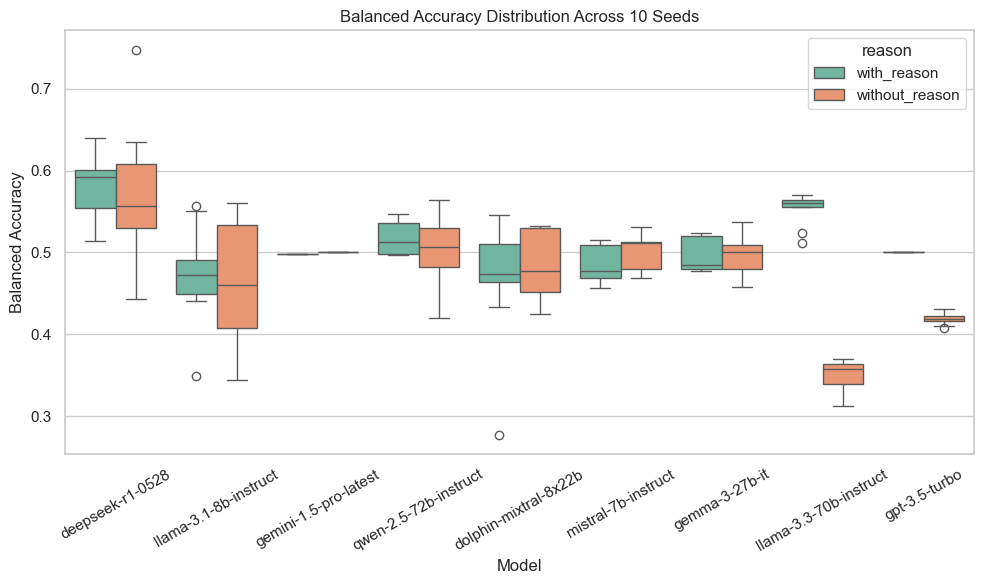

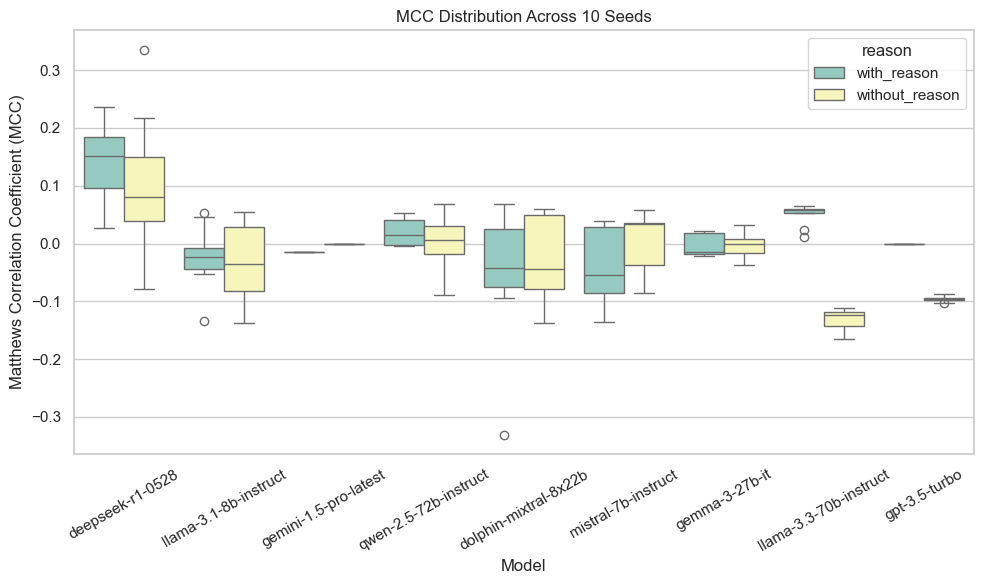

                     model          reason  balanced_accuracy_mean  \
0         deepseek-r1-0528     with_reason                0.582657   
1         deepseek-r1-0528  without_reason                0.570225   
2    dolphin-mixtral-8x22b     with_reason                0.466961   
3    dolphin-mixtral-8x22b  without_reason                0.483929   
4    gemini-1.5-pro-latest     with_reason                0.497899   
5    gemini-1.5-pro-latest  without_reason                0.500000   
6           gemma-3-27b-it     with_reason                0.496919   
7           gemma-3-27b-it  without_reason                0.496151   
8            gpt-3.5-turbo     with_reason                0.500000   
9            gpt-3.5-turbo  without_reason                0.418908   
10   llama-3.1-8b-instruct     with_reason                0.471774   
11   llama-3.1-8b-instruct  without_reason                0.465655   
12  llama-3.3-70b-instruct     with_reason                0.553291   
13  llama-3.3-70b-in

In [29]:
# === Step 1: Collect all summary.json files recursively ===

base_dir = "stat_eval/"
data = []

for model_name in os.listdir(base_dir):
    model_path = os.path.join(base_dir, model_name)
    if not os.path.isdir(model_path):
        continue
    for prompt_type in ["with_reason", "without_reason"]:
        prompt_path = os.path.join(model_path, prompt_type)
        if not os.path.isdir(prompt_path):
            continue
        for timestamp_folder in os.listdir(prompt_path):
            ts_path = os.path.join(prompt_path, timestamp_folder)
            if not os.path.isdir(ts_path):
                continue
            for seed_folder in os.listdir(ts_path):
                seed_path = os.path.join(ts_path, seed_folder)
                summary_path = os.path.join(seed_path, "summary.json")
                if os.path.exists(summary_path):
                    with open(summary_path, "r") as f:
                        summary = json.load(f)
                        data.append(summary)

# === Step 2: Create DataFrame ===

df = pd.DataFrame(data)

# === Step 3: Visualization ===

# sns.set(style="whitegrid")

# === Balanced Accuracy Boxplot ===
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='model', y='balanced_accuracy', hue='reason', palette='Set2')
plt.title("Balanced Accuracy Distribution Across 10 Seeds")
plt.ylabel("Balanced Accuracy")
plt.xlabel("Model")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# === MCC Boxplot ===
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='model', y='mcc', hue='reason', palette='Set3')
plt.title("MCC Distribution Across 10 Seeds")
plt.ylabel("Matthews Correlation Coefficient (MCC)")
plt.xlabel("Model")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# === Step 4: Compute aggregated statistics ===

agg_df = df.groupby(["model", "reason"]).agg({
    "balanced_accuracy": ["mean", "std"],
    "mcc": ["mean", "std"]
}).reset_index()

# Flatten columns
agg_df.columns = ['model', 'reason', 'balanced_accuracy_mean', 'balanced_accuracy_std', 'mcc_mean', 'mcc_std']

print(agg_df)


In [31]:
agg_df.to_csv('stats.csv', index=False)